#### Import libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

####1.  Load dataset from the given URL

In [21]:
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data"

columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
    'LSTAT', 'MEDV'
]

df = pd.read_csv(
    data_url,
    sep=r'\s+',
    header=None,
    names=columns
)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


#### 2. Split the Dataset

In [22]:
X = df.drop('MEDV', axis=1)   # features
y = df['MEDV']                # target (house price)

# Train-Test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (404, 13)  X_test: (102, 13)
y_train: (404,)  y_test: (102,)


#### 3. Train models

In [6]:
lr_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.5)

lr_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

print("All 3 models trained successfully ✅")

All 3 models trained successfully ✅


#### 4. Evaluate Models

In [23]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    return mse, rmse, r2, mae

lr_mse,lr_rmse,lr_r2,lr_mae = evaluate_model(lr_model,    X_test, y_test)
ridge_mse, ridge_rmse, ridge_r2, ridge_mae = evaluate_model(ridge_model, X_test, y_test)
lasso_mse, lasso_rmse, lasso_r2, lasso_mae = evaluate_model(lasso_model, X_test, y_test)

print("Linear Regression -> MSE: {:.3f}, RMSE: {:.3f}, R2: {:.3f}, MAE: {:.3f}".format(lr_mse, lr_rmse, lr_r2, lr_mae))
print("Ridge Regression   -> MSE: {:.3f}, RMSE: {:.3f}, R2: {:.3f}, MAE: {:.3f}".format(ridge_mse, ridge_rmse, ridge_r2, ridge_mae))
print("Lasso Regression   -> MSE: {:.3f}, RMSE: {:.3f}, R2: {:.3f}, MAE: {:.3f}".format(lasso_mse, lasso_rmse, lasso_r2, lasso_mae))


Linear Regression -> MSE: 27.950, RMSE: 5.287, R2: 0.741, MAE: 3.887
Ridge Regression   -> MSE: 28.234, RMSE: 5.314, R2: 0.739, MAE: 3.856
Lasso Regression   -> MSE: 31.408, RMSE: 5.604, R2: 0.709, MAE: 3.950


#### 5. Comparison Table

In [27]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MSE":   [lr_mse, ridge_mse, lasso_mse],
    "RMSE":  [lr_rmse, ridge_rmse, lasso_rmse],
    "R²":    [lr_r2, ridge_r2, lasso_r2],
    "MAE":   [lr_mae, ridge_mae, lasso_mae]
})

results_df = results_df.round(3)
results_df


,Model,MSE,RMSE,R²,MAE
0,Linear Regression,27.950,5.287,0.741,3.887
1,Ridge Regression,28.234,5.314,0.739,3.856
2,Lasso Regression,31.408,5.604,0.709,3.950


#### Visual comparison of the models

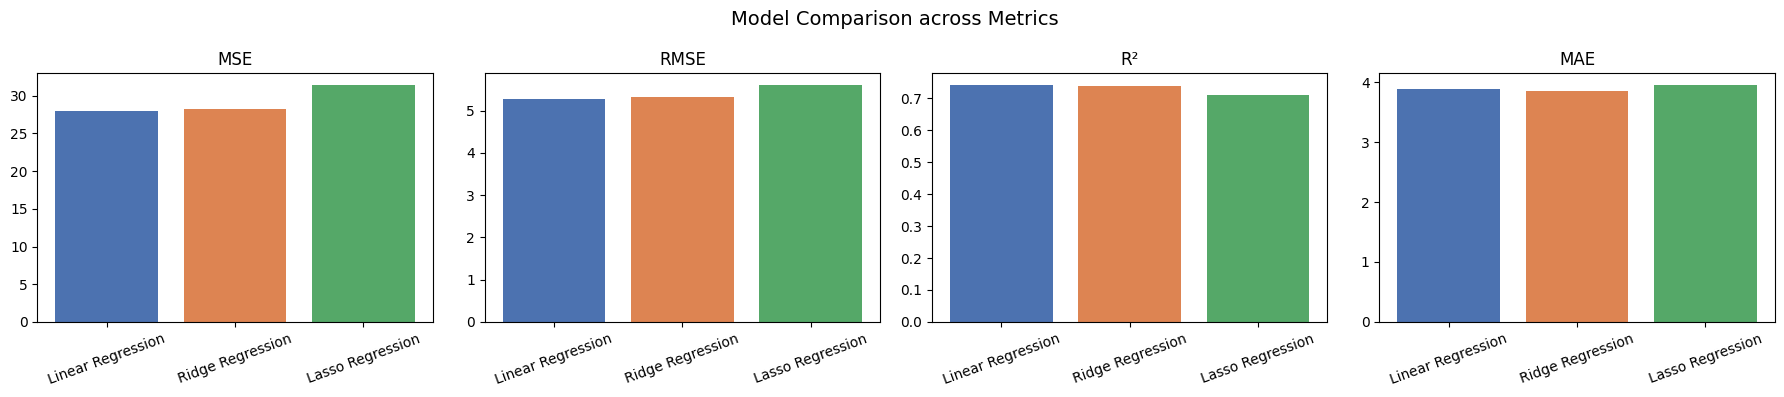

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics = ["MSE", "RMSE", "R²", "MAE"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, metrics):
    ax.bar(results_df["Model"], results_df[metric], color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Model Comparison across Metrics", fontsize=14)
plt.tight_layout()
plt.show()
